In [3]:
# --- IMPORTS NÉCESSAIRES ---
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve

# PyTorch specific imports
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

print("Libraries loaded.")

# --- CONFIGURATION DES CHEMINS DE FICHIERS (ADAPTÉS À KAGGLE) ---
input_dir = '/kaggle/input/competitions/ai-team-challenge-3/'
train_file = input_dir + 'train_dataset.h5'
test_file = input_dir + 'test_dataset.h5'
sample_submission_file = input_dir + 'sample_submission.csv'

print(f"Fichier d'entraînement : {train_file}")
print(f"Fichier de test : {test_file}")
print(f"Fichier de soumission : {sample_submission_file}")

# --- DÉFINIR LE PÉRIPHÉRIQUE (CPU ou GPU) ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ====================================================================================================
# --- PARTIE 1 : CHARGEMENT ET NETTOYAGE ULTRA-ROBUSTE DES DONNÉES ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 1 : CHARGEMENT ET NETTOYAGE ULTRA-ROBUSTE DES DONNÉES ---")
print("="*80)

print("\nChargement des données d'entraînement...")
with h5py.File(train_file, 'r') as hf_train:
    X_train_raw = hf_train['X'][:].astype(np.float64) # Commençons en float64 pour la robustesse au chargement
    y_train_raw = hf_train['y'][:]

print("Chargement des données de test...")
with h5py.File(test_file, 'r') as hf_test:
    X_test_raw = hf_test['X'][:].astype(np.float64) 

print("Données chargées et converties en float64.")

# Vérification initiale des Inf et NaN
print("\n--- Détection initiale des Inf et NaN ---")
print(f"NaN dans X_train_raw : {np.sum(np.isnan(X_train_raw))}")
print(f"Inf dans X_train_raw : {np.sum(np.isinf(X_train_raw))}")
print(f"NaN dans X_test_raw : {np.sum(np.isnan(X_test_raw))}")
print(f"Inf dans X_test_raw : {np.sum(np.isinf(X_test_raw))}")

# Créer des copies pour le traitement
X_train_processed = np.copy(X_train_raw)
X_test_processed = np.copy(X_test_raw)

# --- Stratégie de Nettoyage ULTRA-ROBUSTE ---
# Cette fois, nous allons d'abord remplacer les valeurs extrêmes par des seuils,
# puis gérer les NaN qui pourraient rester.

print("\n--- Traitement ULTRA-ROBUSTE des Inf et NaN/Valeurs extrêmes ---")

# Définir des seuils de clipping très larges mais finis
# float64 a une plage d'environ +/- 1.8e308. Vos e+38 sont déjà trop.
# Nous allons utiliser une plage un peu plus petite que la limite de float64 pour éviter l'overflow
# lors des calculs ultérieurs (moyenne, std, etc.).
# Choisissons +/- 1e300 comme des limites "sûres".
# Ou même plus agressivement, des limites basées sur les percentiles ou une connaissance du signal.
# Pour l'instant, utilisons une limite générique mais "sûre".

# Identifiez des valeurs "normales" du signal (par exemple, 99ème percentile des valeurs finies)
# Ceci est une heuristique pour trouver une plage de valeurs "raisonnables"
finite_values = X_train_processed[np.isfinite(X_train_processed)]
if len(finite_values) > 0:
    q1, q99 = np.percentile(finite_values, [1, 99]) # 1er et 99ème percentile des valeurs finies
    # Définir des seuils de clipping basés sur ces percentiles avec une marge
    clip_lower = q1 - 10 * (q99 - q1) # Par exemple, 10 fois l'intervalle interquartile en dessous
    clip_upper = q99 + 10 * (q99 - q1) # Et au-dessus
    # Mais si les q1, q99 sont déjà très grandes/petites, ceci peut rester un problème.
    # Assurons-nous que les limites sont finies et ne sont pas extrêmes non plus.
    clip_lower = max(clip_lower, -1e10) # Ne pas aller au-delà d'une limite fixe très large
    clip_upper = min(clip_upper, 1e10)  # Ne pas aller au-delà d'une limite fixe très large
else: # Si toutes les valeurs étaient Inf/NaN
    clip_lower = -1e10
    clip_upper = 1e10

print(f"Seuils de clipping définis : [{clip_lower:.2e}, {clip_upper:.2e}]")

# 1. Clipper les valeurs extrêmes (Inf inclus car Inf > clip_upper)
# np.clip est robuste
X_train_processed = np.clip(X_train_processed, clip_lower, clip_upper)
X_test_processed = np.clip(X_test_processed, clip_lower, clip_upper)

# 2. Après clipping, il ne devrait plus y avoir d'Inf. Il pourrait y avoir des NaN si la donnée originale était NaN.
# Remplacer les NaN restants par 0.0 (valeur neutre pour un signal)
X_train_processed = np.nan_to_num(X_train_processed, nan=0.0)
X_test_processed = np.nan_to_num(X_test_processed, nan=0.0)

# Vérification finale après traitement
print("\n--- Vérification après traitement ULTRA-ROBUSTE ---")
print(f"NaN dans X_train_processed : {np.sum(np.isnan(X_train_processed))}")
print(f"Inf dans X_train_processed : {np.sum(np.isinf(X_train_processed))}")
print(f"NaN dans X_test_processed : {np.sum(np.isnan(X_test_processed))}")
print(f"Inf dans X_test_processed : {np.sum(np.isinf(X_test_processed))}")

# Calcul des min/max globaux sur les données propres
min_global_val = np.min(X_train_processed)
max_global_val = np.max(X_train_processed)
print(f"Min global après traitement : {min_global_val:.4e}")
print(f"Max global après traitement : {max_global_val:.4e}")

# Conversion finale en float32 pour PyTorch et utilisation GPU
X_train_processed = X_train_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)
print(f"Données finales converties en {X_train_processed.dtype}")


print("\nPARTIE 1 (Chargement et Nettoyage ULTRA-ROBUSTE) terminée. "
      "Vérifiez que les nombres de NaN/Inf sont à 0 et que min/max sont finis.")

Libraries loaded.
Fichier d'entraînement : /kaggle/input/competitions/ai-team-challenge-3/train_dataset.h5
Fichier de test : /kaggle/input/competitions/ai-team-challenge-3/test_dataset.h5
Fichier de soumission : /kaggle/input/competitions/ai-team-challenge-3/sample_submission.csv
Using device: cuda

--- PARTIE 1 : CHARGEMENT ET NETTOYAGE ULTRA-ROBUSTE DES DONNÉES ---

Chargement des données d'entraînement...
Chargement des données de test...
Données chargées et converties en float64.

--- Détection initiale des Inf et NaN ---
NaN dans X_train_raw : 0
Inf dans X_train_raw : 64760
NaN dans X_test_raw : 0
Inf dans X_test_raw : 29406

--- Traitement ULTRA-ROBUSTE des Inf et NaN/Valeurs extrêmes ---
Seuils de clipping définis : [-1.00e+10, 1.00e+10]

--- Vérification après traitement ULTRA-ROBUSTE ---
NaN dans X_train_processed : 0
Inf dans X_train_processed : 0
NaN dans X_test_processed : 0
Inf dans X_test_processed : 0
Min global après traitement : -1.0000e+10
Max global après traitement 


--- PARTIE 2 : ANALYSE EXPLORATOIRE DES DONNÉES (EDA) SUR DONNÉES PROPRES ---

--- Inspection des formes de données ---
X_train_processed (échantillons, points_par_seconde) : (14000, 4096)
y_train_raw (échantillons,) : (14000,)
X_test_processed (échantillons, points_par_seconde) : (6000, 4096)
Type de données de X_train_processed : float32

Chaque snippet de 1 seconde contient 4096 points de données.

--- Distribution des classes dans l'ensemble d'entraînement ---
0    13160
1      840
Name: count, dtype: int64
Proportion de classe 1 (Signal) : 0.06
Proportion de classe 0 (Bruit) : 0.94

--- Visualisation d'exemples de signaux (après nettoyage) ---


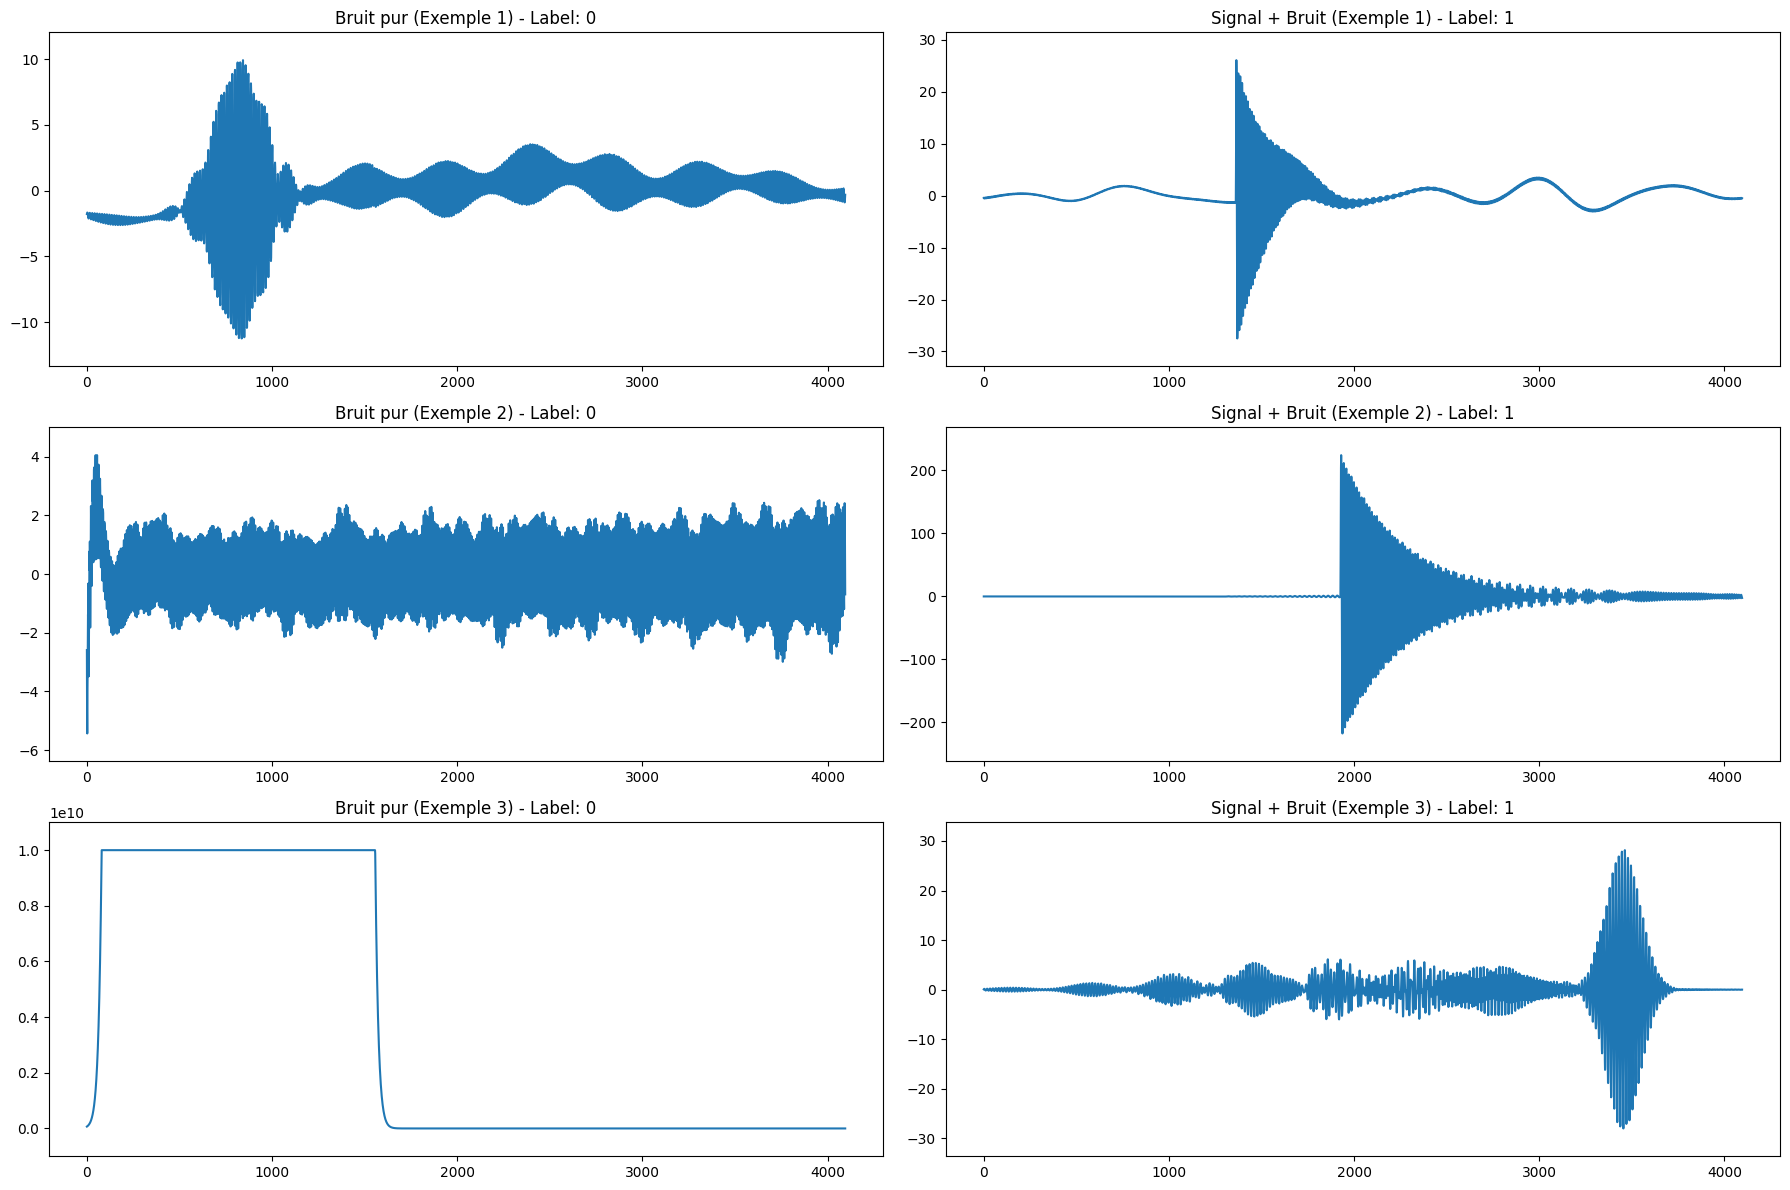


--- Statistiques descriptives de X_train_processed ---
Valeur minimale : -10000000000.0000
Valeur maximale : 10000000000.0000
Moyenne : 112277992.0000
Écart-type : 1371240064.0000

PARTIE 2 (EDA) terminée.


In [4]:
# --- IMPORTS NÉCESSAIRES ---
# Assurez-vous d'avoir exécuté la partie 1 pour avoir les imports et les données chargées
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ====================================================================================================
# --- PARTIE 2 : ANALYSE EXPLORATOIRE DES DONNÉES (EDA) SUR DONNÉES PROPRES ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 2 : ANALYSE EXPLORATOIRE DES DONNÉES (EDA) SUR DONNÉES PROPRES ---")
print("="*80)

# X_train_processed, y_train_raw, X_test_processed sont les variables de la PARTIE 1

print("\n--- Inspection des formes de données ---")
print(f"X_train_processed (échantillons, points_par_seconde) : {X_train_processed.shape}")
print(f"y_train_raw (échantillons,) : {y_train_raw.shape}")
print(f"X_test_processed (échantillons, points_par_seconde) : {X_test_processed.shape}")
print(f"Type de données de X_train_processed : {X_train_processed.dtype}")

n_features = X_train_processed.shape[1]
print(f"\nChaque snippet de 1 seconde contient {n_features} points de données.")

print("\n--- Distribution des classes dans l'ensemble d'entraînement ---")
class_counts = pd.Series(y_train_raw).value_counts()
print(class_counts)
print(f"Proportion de classe 1 (Signal) : {class_counts[1] / len(y_train_raw):.2f}")
print(f"Proportion de classe 0 (Bruit) : {class_counts[0] / len(y_train_raw):.2f}")

# Visualisation de quelques exemples de signaux (maintenant qu'ils sont propres)
print("\n--- Visualisation d'exemples de signaux (après nettoyage) ---")
plt.figure(figsize=(18, 12))

idx_noise = np.where(y_train_raw == 0)[0]
idx_signal = np.where(y_train_raw == 1)[0]

# Tracer 3 exemples de bruit
for i in range(3):
    plt.subplot(3, 2, i*2 + 1)
    sample_data = X_train_processed[idx_noise[i]]
    plt.plot(sample_data)
    plt.title(f"Bruit pur (Exemple {i+1}) - Label: {y_train_raw[idx_noise[i]]}")
    # Ajuster les limites Y pour chaque graphique individuellement pour mieux voir les variations
    y_min_curr, y_max_curr = np.min(sample_data), np.max(sample_data)
    # Ajouter une petite marge, éviter une marge de 0 si les données sont (presque) plates
    margin = (y_max_curr - y_min_curr) * 0.1 if (y_max_curr - y_min_curr) > 0 else 0.1 
    plt.ylim(y_min_curr - margin, y_max_curr + margin) 

# Tracer 3 exemples de signal + bruit
for i in range(3):
    plt.subplot(3, 2, i*2 + 2)
    sample_data = X_train_processed[idx_signal[i]]
    plt.plot(sample_data)
    plt.title(f"Signal + Bruit (Exemple {i+1}) - Label: {y_train_raw[idx_signal[i]]}")
    y_min_curr, y_max_curr = np.min(sample_data), np.max(sample_data)
    margin = (y_max_curr - y_min_curr) * 0.1 if (y_max_curr - y_min_curr) > 0 else 0.1
    plt.ylim(y_min_curr - margin, y_max_curr + margin) 

plt.tight_layout()
plt.show()

# Statistiques descriptives sur les données traitées
print("\n--- Statistiques descriptives de X_train_processed ---")
print(f"Valeur minimale : {np.min(X_train_processed):.4f}")
print(f"Valeur maximale : {np.max(X_train_processed):.4f}")
print(f"Moyenne : {np.mean(X_train_processed):.4f}")
print(f"Écart-type : {np.std(X_train_processed):.4f}")
print("\nPARTIE 2 (EDA) terminée.")

In [6]:
# --- IMPORTS NÉCESSAIRES ---
# Assurez-vous d'avoir exécuté la partie 1 et 2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch specific imports
import torch
from torch.utils.data import Dataset, DataLoader

# ====================================================================================================
# --- PARTIE 3 : PRÉPARATION DES DONNÉES & FEATURE ENGINEERING ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 3 : PRÉPARATION DES DONNÉES & FEATURE ENGINEERING ---")
print("="*80)

# X_train_processed, y_train_raw, X_test_processed sont les variables de la PARTIE 1

# 3.1 Standardisation des séries temporelles
# Très important pour les modèles de Deep Learning
print("\nStandardisation des séries temporelles...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed) # Appliquer la même transformation aux données de test

print(f"Moyenne de X_train_scaled : {np.mean(X_train_scaled):.4f}")
print(f"Écart-type de X_train_scaled : {np.std(X_train_scaled):.4f}")


# 3.2 Remodelage des données pour PyTorch (ajout d'une dimension de canal)
# PyTorch Conv1D attend une entrée de forme (batch_size, n_channels, seq_len)
# Mais quand on le charge dans un Dataset, on prépare (seq_len, n_channels)
# Ici, n_channels = 1
X_train_tensor = torch.from_numpy(X_train_scaled).float().unsqueeze(1) # Ajoute la dimension du canal à la 2ème position
X_test_tensor = torch.from_numpy(X_test_scaled).float().unsqueeze(1)
y_train_tensor = torch.from_numpy(y_train_raw).float().unsqueeze(1) # Labels comme (batch_size, 1)

print(f"Forme de X_train_tensor pour PyTorch : {X_train_tensor.shape} (échantillons, canaux, longueur_série)")
print(f"Forme de y_train_tensor pour PyTorch : {y_train_tensor.shape}")


# 3.3 Division en ensembles d'entraînement et de validation
# Utilisez les données temporelles standardisées
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, random_state=42, stratify=y_train_raw # stratify utilise le numpy array original
)

print(f"\nForme finale de X_train_split (pour entraînement CNN) : {X_train_split.shape}")
print(f"Forme finale de y_train_split (pour entraînement CNN) : {y_train_split.shape}")
print(f"Forme finale de X_val_split (pour validation CNN) : {X_val_split.shape}")
print(f"Forme finale de y_val_split (pour validation CNN) : {y_val_split.shape}")

# Vérification de la proportion des classes dans les splits
print("\nProportion des classes dans y_train_split :")
print(pd.Series(y_train_split.cpu().numpy().flatten()).value_counts(normalize=True))
print("Proportion des classes dans y_val_split :")
print(pd.Series(y_val_split.cpu().numpy().flatten()).value_counts(normalize=True))


# 3.4 Création de Dataset et DataLoader PyTorch
class CosmicSignalDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

# Définir la taille du batch
BATCH_SIZE = 64 # Taille de batch courante pour le GPU

train_dataset = CosmicSignalDataset(X_train_split, y_train_split)
val_dataset = CosmicSignalDataset(X_val_split, y_val_split)
test_dataset = CosmicSignalDataset(X_test_tensor) # Le test_dataset n'a pas de labels y

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nNombre de batches d'entraînement : {len(train_loader)}")
print(f"Nombre de batches de validation : {len(val_loader)}")
print(f"Nombre de batches de test : {len(test_loader)}")
print("\nPARTIE 3 (Préparation des Données) terminée.")


--- PARTIE 3 : PRÉPARATION DES DONNÉES & FEATURE ENGINEERING ---

Standardisation des séries temporelles...
Moyenne de X_train_scaled : 0.0000
Écart-type de X_train_scaled : 1.0000
Forme de X_train_tensor pour PyTorch : torch.Size([14000, 1, 4096]) (échantillons, canaux, longueur_série)
Forme de y_train_tensor pour PyTorch : torch.Size([14000, 1])

Forme finale de X_train_split (pour entraînement CNN) : torch.Size([11200, 1, 4096])
Forme finale de y_train_split (pour entraînement CNN) : torch.Size([11200, 1])
Forme finale de X_val_split (pour validation CNN) : torch.Size([2800, 1, 4096])
Forme finale de y_val_split (pour validation CNN) : torch.Size([2800, 1])

Proportion des classes dans y_train_split :
0.0    0.94
1.0    0.06
Name: proportion, dtype: float64
Proportion des classes dans y_val_split :
0.0    0.94
1.0    0.06
Name: proportion, dtype: float64

Nombre de batches d'entraînement : 175
Nombre de batches de validation : 44
Nombre de batches de test : 94

PARTIE 3 (Préparatio

In [7]:
# --- IMPORTS NÉCESSAIRES ---
# Assurez-vous d'avoir exécuté les parties précédentes
import torch
import torch.nn as nn

# ====================================================================================================
# --- PARTIE 4 : MODÉLISATION (CNN 1D avec PyTorch) ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 4 : MODÉLISATION (CNN 1D avec PyTorch) ---")
print("="*80)

# n_features est la longueur de la série temporelle (vient de la PARTIE 2)
# device est défini dans la PARTIE 1

class CNN1DClassifier(nn.Module):
    def __init__(self, input_len):
        super(CNN1DClassifier, self).__init__()
        # PyTorch Conv1d prend (in_channels, out_channels, kernel_size)
        # in_channels = 1 car nous avons 1 canal (signal mono)
        
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, padding=2) # padding='same'
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1) # padding='same'
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.dropout2 = nn.Dropout(0.2)
        
        # Pour déterminer la taille d'entrée de la couche linéaire après Flatten,
        # nous devons calculer la taille de sortie des couches convolutives.
        # Taille de sortie Conv1D : (input_len - kernel_size + 2*padding) / stride + 1
        # Taille de sortie MaxPool1D : input_len / pool_size
        
        # Calculons la taille après les couches convolutives pour input_len (n_features)
        # Après conv1 + pool1:
        len_after_conv1 = (input_len - 5 + 2*2) + 1 # Avec padding=2 et kernel=5
        len_after_pool1 = len_after_conv1 // 2
        
        # Après conv2 + pool2:
        len_after_conv2 = (len_after_pool1 - 3 + 2*1) + 1 # Avec padding=1 et kernel=3
        len_after_pool2 = len_after_conv2 // 2
        
        # La couche Flatten aura une taille de out_channels_last * len_after_pool_last
        flattened_size = 64 * len_after_pool2
        
        self.fc1 = nn.Linear(flattened_size, 64)
        self.relu3 = nn.ReLU()
        self.dropout3 = nn.Dropout(0.3)
        self.fc2 = nn.Linear(64, 1) # Output unique pour classification binaire

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.dropout1(x)
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.dropout2(x)
        
        x = x.view(x.size(0), -1) # Flatten
        
        x = self.relu3(self.fc1(x))
        x = self.dropout3(x)
        x = self.fc2(x) # Pas de Sigmoid ici, elle sera appliquée dans la fonction de perte (BCEWithLogitsLoss)
        return x

# Instancier le modèle et l'envoyer au périphérique (CPU/GPU)
model = CNN1DClassifier(input_len=n_features).to(device) # n_features vient de PARTIE 2

print("\nArchitecture du modèle PyTorch :")
print(model)

# Vérifier la taille d'entrée calculée pour la première couche linéaire
# C'est un point critique pour les CNN. Si le calcul est faux, le modèle ne se construira pas.
# La façon la plus simple est de passer un tenseur factice (dummy tensor)
try:
    dummy_input = torch.randn(1, 1, n_features).to(device) # (batch_size, channels, seq_len)
    _ = model(dummy_input)
    print(f"\nModèle construit avec succès. Taille de l'entrée de la couche linéaire: {model.fc1.in_features}")
except RuntimeError as e:
    print(f"\nErreur lors de la construction du modèle ou calcul de la taille aplatie: {e}")
    print("Vérifiez le calcul de 'flattened_size' dans la classe CNN1DClassifier.")

print("\nPARTIE 4 (Modélisation) terminée.")


--- PARTIE 4 : MODÉLISATION (CNN 1D avec PyTorch) ---

Architecture du modèle PyTorch :
CNN1DClassifier(
  (conv1): Conv1d(1, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.2, inplace=False)
  (conv2): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.2, inplace=False)
  (fc1): Linear(in_features=65536, out_features=64, bias=True)
  (relu3): ReLU()
  (dropout3): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=1, bias=True)
)

Modèle construit avec succès. Taille de l'entrée de la couche linéaire: 65536

PARTIE 4 (Modélisation) terminée.



--- PARTIE 5 : ENTRAÎNEMENT DU MODÈLE ---

Début de l'entraînement sur cuda avec 50 époques max...
Epoch 1/50: Train Loss: 0.2673, Val Loss: 0.2673, Val AUC: 0.5521
  --> Meilleur modèle sauvegardé (Val AUC: 0.5521)
Epoch 2/50: Train Loss: 0.2332, Val Loss: 0.2724, Val AUC: 0.5368
Epoch 3/50: Train Loss: 0.2334, Val Loss: 0.2636, Val AUC: 0.5717
  --> Meilleur modèle sauvegardé (Val AUC: 0.5717)
Epoch 4/50: Train Loss: 0.2312, Val Loss: 0.2559, Val AUC: 0.5361
Epoch 5/50: Train Loss: 0.2290, Val Loss: 0.2481, Val AUC: 0.5347
Epoch 6/50: Train Loss: 0.2307, Val Loss: 0.2270, Val AUC: 0.5339
Epoch 7/50: Train Loss: 0.2302, Val Loss: 0.2332, Val AUC: 0.5137
Epoch 8/50: Train Loss: 0.2275, Val Loss: 0.2457, Val AUC: 0.5196
Epoch 9/50: Train Loss: 0.2282, Val Loss: 0.2524, Val AUC: 0.5300
Epoch 10/50: Train Loss: 0.2281, Val Loss: 0.2423, Val AUC: 0.5219
Epoch 11/50: Train Loss: 0.2264, Val Loss: 0.2655, Val AUC: 0.4848
Epoch 12/50: Train Loss: 0.2270, Val Loss: 0.2671, Val AUC: 0.5368
Epo

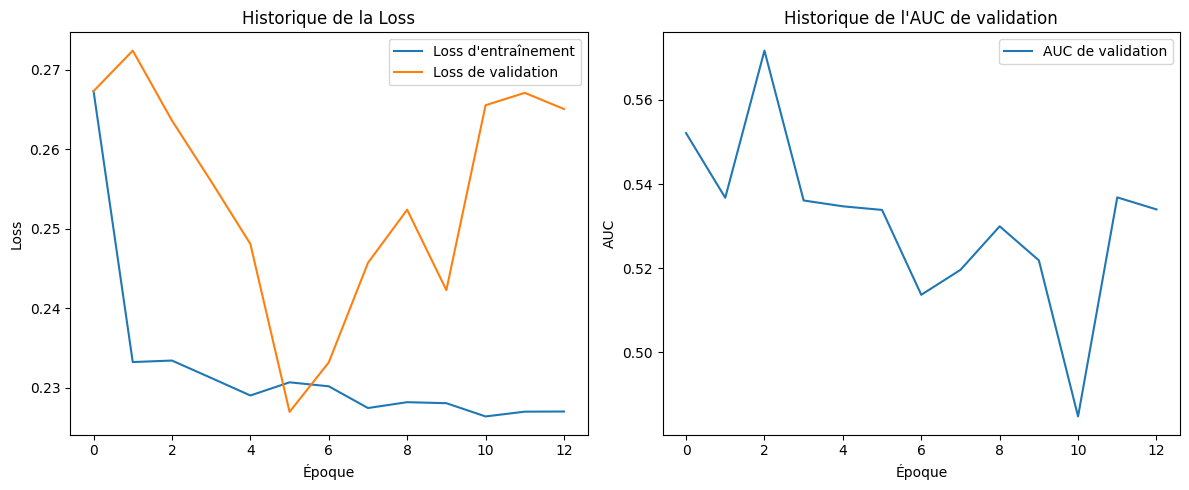


PARTIE 5 (Entraînement) terminée.


In [8]:
# --- IMPORTS NÉCESSAIRES ---
# Assurez-vous d'avoir exécuté les parties précédentes
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import os # Pour sauvegarder le modèle

# ====================================================================================================
# --- PARTIE 5 : ENTRAÎNEMENT DU MODÈLE ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 5 : ENTRAÎNEMENT DU MODÈLE ---")
print("="*80)

# model, train_loader, val_loader, device sont définis dans les parties précédentes

# Hyperparamètres d'entraînement
LEARNING_RATE = 0.001
NUM_EPOCHS = 50 # Le Early Stopping arrêtera avant si la performance stagne
PATIENCE = 10 # Pour Early Stopping
BEST_MODEL_PATH = 'best_pytorch_cnn_model.pth'

# Fonction de perte : BCEWithLogitsLoss combine Sigmoid et Binary Cross-Entropy
# C'est numériquement plus stable. Le modèle ne doit donc PAS avoir de nn.Sigmoid() en dernière couche.
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Boucle d'entraînement ---
best_val_auc = -1.0
epochs_no_improve = 0
history_loss_train = []
history_loss_val = []
history_auc_val = []

print(f"\nDébut de l'entraînement sur {device} avec {NUM_EPOCHS} époques max...")

for epoch in range(NUM_EPOCHS):
    model.train() # Mettre le modèle en mode entraînement (active Dropout)
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() # Réinitialiser les gradients
        
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, labels) # Calculer la perte
        
        loss.backward() # Backward pass (calcul des gradients)
        optimizer.step() # Mettre à jour les poids
        
        running_loss += loss.item() * inputs.size(0) # Accumuler la perte
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    history_loss_train.append(epoch_train_loss)

    # --- Évaluation sur l'ensemble de validation ---
    model.eval() # Mettre le modèle en mode évaluation (désactive Dropout)
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): # Ne pas calculer les gradients pendant la validation
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            # Appliquer Sigmoid pour obtenir des probabilités entre 0 et 1 pour AUC
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    
    epoch_val_loss = val_loss / len(val_loader.dataset)
    history_loss_val.append(epoch_val_loss)
    
    # Calcul de l'AUC-ROC sur l'ensemble de validation
    try:
        epoch_val_auc = roc_auc_score(all_labels, all_preds)
    except ValueError: # Peut arriver si une classe est absente dans un batch ou dans le val_set
        epoch_val_auc = 0.5 # Dans ce cas, l'AUC n'est pas définissable, on met une valeur neutre
    history_auc_val.append(epoch_val_auc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, "
          f"Val AUC: {epoch_val_auc:.4f}")
    
    # --- Early Stopping et Sauvegarde du meilleur modèle ---
    if epoch_val_auc > best_val_auc:
        best_val_auc = epoch_val_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH) # Sauvegarder les poids du modèle
        print(f"  --> Meilleur modèle sauvegardé (Val AUC: {best_val_auc:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            print(f"Early stopping après {PATIENCE} époques sans amélioration.")
            break

print("\nEntraînement terminé.")

# --- Tracer l'historique de l'entraînement ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_loss_train, label='Loss d\'entraînement')
plt.plot(history_loss_val, label='Loss de validation')
plt.title('Historique de la Loss')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_auc_val, label='AUC de validation')
plt.title('Historique de l\'AUC de validation')
plt.xlabel('Époque')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

print("\nPARTIE 5 (Entraînement) terminée.")

In [9]:
print("\n" + "="*80)
print("--- PARTIE 6 : ÉVALUATION ET PRÉDICTION ---")
print("="*80)

# model, BEST_MODEL_PATH, test_loader, val_loader, device, n_features sont définis précédemment

# Charger le meilleur modèle sauvegardé
# Assurez-vous d'instancier le modèle AVANT de charger les poids
best_model = CNN1DClassifier(input_len=n_features).to(device)
if os.path.exists(BEST_MODEL_PATH):
    best_model.load_state_dict(torch.load(BEST_MODEL_PATH))
    best_model.eval() # Mettre en mode évaluation après chargement
    print(f"\nMeilleur modèle chargé depuis '{BEST_MODEL_PATH}'")
else:
    print(f"\nAvertissement: Le fichier '{BEST_MODEL_PATH}' n'a pas été trouvé. Utilisation du modèle non entraîné.")
    best_model = model # Utiliser le modèle tel quel (dernier état de l'entraînement)


# --- Évaluation finale sur l'ensemble de validation (avec le meilleur modèle) ---
print("\n--- Évaluation du MEILLEUR modèle sur l'ensemble de validation ---")
val_loss = 0.0
all_preds_val = []
all_labels_val = []
criterion = nn.BCEWithLogitsLoss() # Redéfinir la fonction de perte

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item() * inputs.size(0)
        preds = torch.sigmoid(outputs).cpu().numpy()
        all_preds_val.extend(preds.flatten())
        all_labels_val.extend(labels.cpu().numpy().flatten())

final_val_loss = val_loss / len(val_loader.dataset)
final_val_auc = roc_auc_score(all_labels_val, all_preds_val)
print(f"Loss finale sur validation : {final_val_loss:.4f}")
print(f"AUC finale sur validation : {final_val_auc:.4f}")


--- PARTIE 6 : ÉVALUATION ET PRÉDICTION ---

Meilleur modèle chargé depuis 'best_pytorch_cnn_model.pth'

--- Évaluation du MEILLEUR modèle sur l'ensemble de validation ---
Loss finale sur validation : 0.2636
AUC finale sur validation : 0.5717


In [10]:
# --- IMPORTS NÉCESSAIRES ---
# Assurez-vous d'avoir exécuté la partie 1 et 2
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch specific imports
import torch
from torch.utils.data import Dataset, DataLoader

# ====================================================================================================
# --- PARTIE 3 : PRÉPARATION DES DONNÉES & FEATURE ENGINEERING ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 3 : PRÉPARATION DES DONNÉES & FEATURE ENGINEERING (AVEC AUGMENTATION) ---")
print("="*80)

# X_train_processed, y_train_raw, X_test_processed sont les variables de la PARTIE 1

# 3.1 Standardisation des séries temporelles
print("\nStandardisation des séries temporelles...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_test_scaled = scaler.transform(X_test_processed) 

print(f"Moyenne de X_train_scaled : {np.mean(X_train_scaled):.4f}")
print(f"Écart-type de X_train_scaled : {np.std(X_train_scaled):.4f}")


# 3.2 Remodelage des données pour PyTorch (ajout d'une dimension de canal)
X_train_tensor = torch.from_numpy(X_train_scaled).float().unsqueeze(1)
X_test_tensor = torch.from_numpy(X_test_scaled).float().unsqueeze(1)
y_train_tensor = torch.from_numpy(y_train_raw).float().unsqueeze(1) 

print(f"Forme de X_train_tensor pour PyTorch : {X_train_tensor.shape} (échantillons, canaux, longueur_série)")


# 3.3 Division en ensembles d'entraînement et de validation
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train_tensor, y_train_tensor, test_size=0.2, random_state=42, stratify=y_train_raw 
)

print(f"\nForme finale de X_train_split (pour entraînement CNN) : {X_train_split.shape}")


# 3.4 Création de Dataset et DataLoader PyTorch (AVEC AUGMENTATION POUR LE TRAIN SET)
class CosmicSignalDataset(Dataset):
    def __init__(self, X, y=None, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        sample_X = self.X[idx]
        
        if self.augment:
            # Augmentation de données (pour l'entraînement seulement)
            # 1. Décalage temporel (Time Shift)
            shift = np.random.randint(-50, 50) # Décaler de -50 à +50 points
            sample_X = torch.roll(sample_X, shifts=shift, dims=-1)
            
            # 2. Changement d'amplitude (Amplitude Scaling)
            scale_factor = np.random.uniform(0.8, 1.2) # Changer l'amplitude de 80% à 120%
            sample_X = sample_X * scale_factor
            
            # 3. Ajout de bruit aléatoire (Noise Injection) - Léger
            # noise = torch.randn_like(sample_X) * np.random.uniform(0.01, 0.05) # Petit bruit aléatoire
            # sample_X = sample_X + noise

        if self.y is not None:
            return sample_X, self.y[idx]
        return sample_X

# Définir la taille du batch
BATCH_SIZE = 64 

# DataLoader pour l'entraînement avec augmentation
train_dataset = CosmicSignalDataset(X_train_split, y_train_split, augment=True)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# DataLoader pour la validation et le test (SANS augmentation)
val_dataset = CosmicSignalDataset(X_val_split, y_val_split, augment=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

test_dataset = CosmicSignalDataset(X_test_tensor, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nNombre de batches d'entraînement (avec augmentation) : {len(train_loader)}")
print(f"Nombre de batches de validation : {len(val_loader)}")
print(f"Nombre de batches de test : {len(test_loader)}")
print("\nPARTIE 3 (Préparation des Données avec Augmentation) terminée.")


--- PARTIE 3 : PRÉPARATION DES DONNÉES & FEATURE ENGINEERING (AVEC AUGMENTATION) ---

Standardisation des séries temporelles...
Moyenne de X_train_scaled : 0.0000
Écart-type de X_train_scaled : 1.0000
Forme de X_train_tensor pour PyTorch : torch.Size([14000, 1, 4096]) (échantillons, canaux, longueur_série)

Forme finale de X_train_split (pour entraînement CNN) : torch.Size([11200, 1, 4096])

Nombre de batches d'entraînement (avec augmentation) : 175
Nombre de batches de validation : 44
Nombre de batches de test : 94

PARTIE 3 (Préparation des Données avec Augmentation) terminée.


In [11]:
# --- IMPORTS NÉCESSAIRES ---
# Assurez-vous d'avoir exécuté les parties précédentes
import torch
import torch.nn as nn

# ====================================================================================================
# --- PARTIE 4 : MODÉLISATION (CNN 1D avec PyTorch - ARCHITECTURE AJUSTÉE) ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 4 : MODÉLISATION (CNN 1D avec PyTorch - ARCHITECTURE AJUSTÉE) ---")
print("="*80)

# n_features est la longueur de la série temporelle (vient de la PARTIE 2)
# device est défini dans la PARTIE 1

class CNN1DClassifier(nn.Module):
    def __init__(self, input_len):
        super(CNN1DClassifier, self).__init__()
        
        # Couche 1: Moins de filtres au début, kernel_size plus petit
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(kernel_size=2)
        self.dropout1 = nn.Dropout(0.3) # Augmenter le dropout
        
        # Couche 2
        self.conv2 = nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(kernel_size=2)
        self.dropout2 = nn.Dropout(0.3) # Augmenter le dropout
        
        # Couche 3 (ajoutée)
        self.conv3 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool1d(kernel_size=2)
        self.dropout3 = nn.Dropout(0.4) # Dropout encore plus élevé
        
        # Calcul de la taille aplatie (flattened_size) après les couches convolutives
        # Input_len est n_features
        len_after_conv1 = (input_len - 3 + 2*1) + 1 # kernel=3, padding=1
        len_after_pool1 = len_after_conv1 // 2
        
        len_after_conv2 = (len_after_pool1 - 3 + 2*1) + 1
        len_after_pool2 = len_after_conv2 // 2
        
        len_after_conv3 = (len_after_pool2 - 3 + 2*1) + 1
        len_after_pool3 = len_after_conv3 // 2
        
        flattened_size = 64 * len_after_pool3 # 64 est out_channels de la dernière conv
        
        # Couches linéaires (plus petites)
        self.fc1 = nn.Linear(flattened_size, 32) # Réduire la taille de la couche linéaire
        self.relu4 = nn.ReLU()
        self.dropout4 = nn.Dropout(0.4) # Dropout élevé ici aussi
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.dropout1(x)
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.dropout2(x)
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.dropout3(x)
        
        x = x.view(x.size(0), -1) # Flatten
        
        x = self.relu4(self.fc1(x))
        x = self.dropout4(x)
        x = self.fc2(x) 
        return x

# Instancier le modèle et l'envoyer au périphérique (CPU/GPU)
model = CNN1DClassifier(input_len=n_features).to(device)

print("\nArchitecture du modèle PyTorch ajustée :")
print(model)

# Vérifier la taille d'entrée calculée pour la première couche linéaire
try:
    dummy_input = torch.randn(1, 1, n_features).to(device) # (batch_size, channels, seq_len)
    _ = model(dummy_input)
    print(f"\nModèle construit avec succès. Taille de l'entrée de la couche linéaire: {model.fc1.in_features}")
except RuntimeError as e:
    print(f"\nErreur lors de la construction du modèle ou calcul de la taille aplatie: {e}")
    print("Vérifiez le calcul de 'flattened_size' dans la classe CNN1DClassifier.")

print("\nPARTIE 4 (Modélisation avec architecture ajustée) terminée.")


--- PARTIE 4 : MODÉLISATION (CNN 1D avec PyTorch - ARCHITECTURE AJUSTÉE) ---

Architecture du modèle PyTorch ajustée :
CNN1DClassifier(
  (conv1): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu1): ReLU()
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.3, inplace=False)
  (conv2): Conv1d(16, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu2): ReLU()
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout2): Dropout(p=0.3, inplace=False)
  (conv3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu3): ReLU()
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout3): Dropout(p=0.4, inplace=False)
  (fc1): Linear(in_features=32768, out_features=32, bias=True)
  (relu4): ReLU()
  (dropout4): Dropout(p=0.4, inplace=False)
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Modèle construit ave


--- PARTIE 5 : ENTRAÎNEMENT DU MODÈLE (AVEC PONDÉRATION DE CLASSE ET AJUSTEMENTS) ---

Poids des classes (pour BCEWithLogitsLoss) : [Classe 0: 0.53, Classe 1: 8.33]

Début de l'entraînement sur cuda avec 100 époques max...
Epoch 1/100: Train Loss: 0.9254, Val Loss: 0.9715, Val AUC: 0.5376
  --> Meilleur modèle sauvegardé (Val AUC: 0.5376)
Epoch 2/100: Train Loss: 0.9280, Val Loss: 0.9450, Val AUC: 0.5333
Epoch 3/100: Train Loss: 0.9147, Val Loss: 0.9368, Val AUC: 0.5343
Epoch 4/100: Train Loss: 0.9106, Val Loss: 0.9442, Val AUC: 0.5534
  --> Meilleur modèle sauvegardé (Val AUC: 0.5534)
Epoch 5/100: Train Loss: 0.9120, Val Loss: 0.9452, Val AUC: 0.5318
Epoch 6/100: Train Loss: 0.9101, Val Loss: 0.9427, Val AUC: 0.5375
Epoch 7/100: Train Loss: 0.9099, Val Loss: 0.9550, Val AUC: 0.5373
Epoch 8/100: Train Loss: 0.9051, Val Loss: 0.9628, Val AUC: 0.5364
Epoch 9/100: Train Loss: 0.9043, Val Loss: 0.9656, Val AUC: 0.5287
Epoch 10/100: Train Loss: 0.9048, Val Loss: 0.9721, Val AUC: 0.5370
Epo

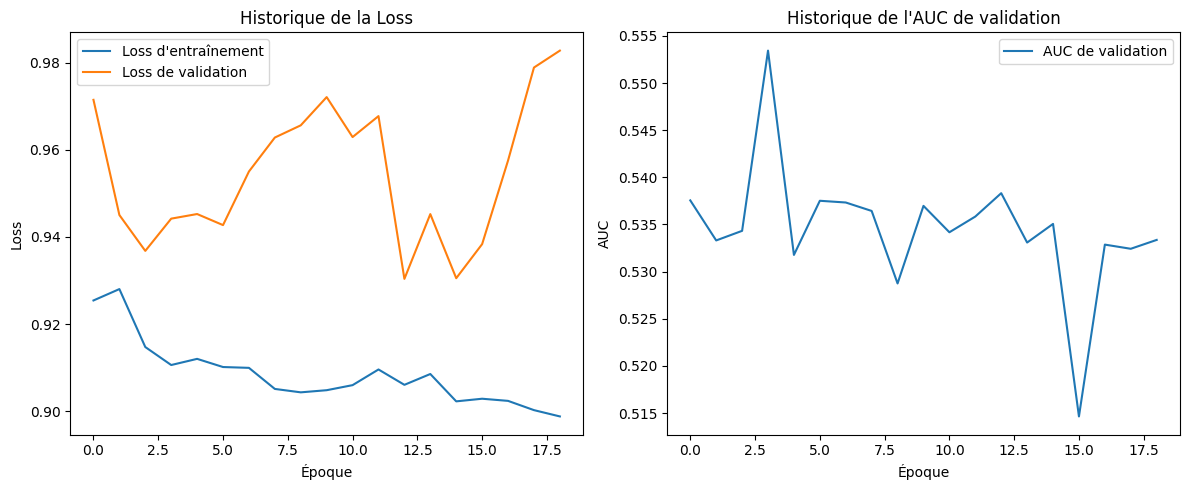


PARTIE 5 (Entraînement) terminée.


In [12]:
# --- IMPORTS NÉCESSAIRES ---
# Assurez-vous d'avoir exécuté les parties précédentes
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import os

# ====================================================================================================
# --- PARTIE 5 : ENTRAÎNEMENT DU MODÈLE (AVEC PONDÉRATION DE CLASSE ET AJUSTEMENTS) ---
# ====================================================================================================
print("\n" + "="*80)
print("--- PARTIE 5 : ENTRAÎNEMENT DU MODÈLE (AVEC PONDÉRATION DE CLASSE ET AJUSTEMENTS) ---")
print("="*80)

# model, train_loader, val_loader, device, y_train_raw (pour calculer les poids) sont définis précédemment

# Hyperparamètres d'entraînement ajustés
LEARNING_RATE = 0.0005 # Taux d'apprentissage réduit pour une convergence plus stable
NUM_EPOCHS = 100 # Plus d'époques, l'Early Stopping gérera l'arrêt
PATIENCE = 15 # Augmenter la patience de l'Early Stopping
BEST_MODEL_PATH = 'best_pytorch_cnn_model_v2.pth' # Nouveau nom pour le modèle

# --- Pondération des Classes (si déséquilibrées) ---
# Calculer les poids des classes pour la fonction de perte
class_counts = pd.Series(y_train_raw).value_counts().sort_index()
total_samples = len(y_train_raw)
# La classe minoritaire (1) aura un poids plus élevé
weight_for_0 = total_samples / (2 * class_counts[0])
weight_for_1 = total_samples / (2 * class_counts[1])
class_weights = torch.tensor([weight_for_0, weight_for_1]).to(device) # Poids pour chaque classe

print(f"\nPoids des classes (pour BCEWithLogitsLoss) : [Classe 0: {weight_for_0:.2f}, Classe 1: {weight_for_1:.2f}]")

# Fonction de perte : BCEWithLogitsLoss avec pondération des classes
# Nous utilisons le poids de la CLASSE POSITIVE (1) pour weight= car c'est un problème binaire.
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([weight_for_1]).to(device))
# Si le déséquilibre est léger, on peut aussi laisser pos_weight par défaut (1.0)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- Boucle d'entraînement ---
best_val_auc = -1.0
epochs_no_improve = 0
history_loss_train = []
history_loss_val = []
history_auc_val = []

print(f"\nDébut de l'entraînement sur {device} avec {NUM_EPOCHS} époques max...")

for epoch in range(NUM_EPOCHS):
    model.train() 
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad() 
        
        outputs = model(inputs) 
        loss = criterion(outputs, labels) 
        
        loss.backward() 
        optimizer.step() 
        
        running_loss += loss.item() * inputs.size(0) 
    
    epoch_train_loss = running_loss / len(train_loader.dataset)
    history_loss_train.append(epoch_train_loss)

    # --- Évaluation sur l'ensemble de validation ---
    model.eval() 
    val_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad(): 
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
            preds = torch.sigmoid(outputs).cpu().numpy()
            all_preds.extend(preds.flatten())
            all_labels.extend(labels.cpu().numpy().flatten())
    
    epoch_val_loss = val_loss / len(val_loader.dataset)
    history_loss_val.append(epoch_val_loss)
    
    try:
        epoch_val_auc = roc_auc_score(all_labels, all_preds)
    except ValueError:
        epoch_val_auc = 0.5 
    history_auc_val.append(epoch_val_auc)
    
    print(f"Epoch {epoch+1}/{NUM_EPOCHS}: "
          f"Train Loss: {epoch_train_loss:.4f}, "
          f"Val Loss: {epoch_val_loss:.4f}, "
          f"Val AUC: {epoch_val_auc:.4f}")
    
    # --- Early Stopping et Sauvegarde du meilleur modèle ---
    # Nous surveillons toujours l'AUC de validation pour sauvegarder le meilleur modèle.
    if epoch_val_auc > best_val_auc:
        best_val_auc = epoch_val_auc
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  --> Meilleur modèle sauvegardé (Val AUC: {best_val_auc:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve == PATIENCE:
            print(f"Early stopping après {PATIENCE} époques sans amélioration.")
            break

print("\nEntraînement terminé.")

# --- Tracer l'historique de l'entraînement ---
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_loss_train, label='Loss d\'entraînement')
plt.plot(history_loss_val, label='Loss de validation')
plt.title('Historique de la Loss')
plt.xlabel('Époque')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_auc_val, label='AUC de validation')
plt.title('Historique de l\'AUC de validation')
plt.xlabel('Époque')
plt.ylabel('AUC')
plt.legend()

plt.tight_layout()
plt.show()

print("\nPARTIE 5 (Entraînement) terminée.")

In [13]:
best_model2 = CNN1DClassifier(input_len=n_features).to(device)
if os.path.exists(BEST_MODEL_PATH):
    best_model2.load_state_dict(torch.load(BEST_MODEL_PATH))
    best_model2.eval() 
    print(f"\nMeilleur modèle chargé depuis '{BEST_MODEL_PATH}'")
else:
    print(f"\nAvertissement: Le fichier '{BEST_MODEL_PATH}' n'a pas été trouvé. "
          f"Veuillez vérifier le chemin ou si le modèle a été sauvegardé. "
          f"Utilisation du modèle entraîné à la fin de la dernière époque.")
    # Dans ce cas, on utilise l'état final du modèle qui est encore en mémoire.
    # Ceci est moins idéal que de charger le "meilleur" mais évite une erreur si le fichier n'est pas trouvé.
    best_model2 = model 


# --- Évaluation finale sur l'ensemble de validation (avec le meilleur modèle) ---
print("\n--- Évaluation du MEILLEUR modèle sur l'ensemble de validation ---")
val_loss = 0.0
all_preds_val = []
all_labels_val = []
criterion = nn.BCEWithLogitsLoss() 

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = best_model2(inputs)
        loss = criterion(outputs, labels)
        val_loss += loss.item() * inputs.size(0)
        preds = torch.sigmoid(outputs).cpu().numpy() 
        all_preds_val.extend(preds.flatten())
        all_labels_val.extend(labels.cpu().numpy().flatten())

final_val_loss = val_loss / len(val_loader.dataset)
final_val_auc = roc_auc_score(all_labels_val, all_preds_val)
print(f"Loss finale sur validation : {final_val_loss:.4f}")
print(f"AUC finale sur validation : {final_val_auc:.4f}")


Meilleur modèle chargé depuis 'best_pytorch_cnn_model_v2.pth'

--- Évaluation du MEILLEUR modèle sur l'ensemble de validation ---
Loss finale sur validation : 0.5769
AUC finale sur validation : 0.5534


In [14]:
print("\n--- Génération des prédictions pour l'ensemble de test ---")
test_predictions = []
best_model.eval() 

with torch.no_grad():
    for inputs in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        preds = torch.sigmoid(outputs).cpu().numpy() 
        test_predictions.extend(preds.flatten())

# --- Génération du fichier de soumission ---
submission_df = pd.read_csv(sample_submission_file)

submission_df['target'] = test_predictions

submission_output_path = 'submission.csv'
submission_df.to_csv(submission_output_path, index=False)

print(f"\nFichier de soumission créé : {submission_output_path}")
print("Premières lignes du fichier de soumission :")
print(submission_df.head())

print("\nPipeline complète exécutée avec succès ! 🎉")


--- Génération des prédictions pour l'ensemble de test ---

Fichier de soumission créé : submission.csv
Premières lignes du fichier de soumission :
              id    target
0  gw_test_00000  0.000154
1  gw_test_00001  0.142553
2  gw_test_00002  0.142553
3  gw_test_00003  0.142553
4  gw_test_00004  0.142553

Pipeline complète exécutée avec succès ! 🎉


In [15]:
from IPython.display import FileLink
FileLink("submission.csv")

/kaggle/working/submission.csv